<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/recitations/07_ImageProcessingRecitation_BinaryImages_ConnectedComponents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL
from scipy.signal import convolve
import random
random.seed(3)

In [ ]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(fname:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        fname: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, fname)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [ ]:
def histogram(img:np.array) -> np.array:
    hist = np.zeros(256, dtype='int16')
    nrows, ncols = img.shape
    for r in range(nrows):
        for c in range(ncols):
            hist[img[r, c]] += 1
    return hist

In [ ]:
def plot_img_hist(img:np.array):
    hist = histogram(img)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))
    axes[0].imshow(img,  cmap='gray', vmin=0, vmax=255)

    axes[1].set_xlim([0, 256])
    axes[1].set_ylim([0, hist[1:-1].max()])
    axes[1].bar(np.arange(len(hist)),height=hist);

In [ ]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(22, 8))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

<div dir="rtl">

## 7.תמונות בינאריות

איך יוצרים תמונה בינארית?

תחילה ע"י ההיסטוגרמה של התמונה נקבע את הסף שיחליט לסווג אם אובייקט או רקע.

בחירת הסף חשובה מאוד כדי שמצד אחד לא נאבד אובייקטים חשובים ומצד שני לא יהיו אובייקטים לא רלוונטים:
<dir>

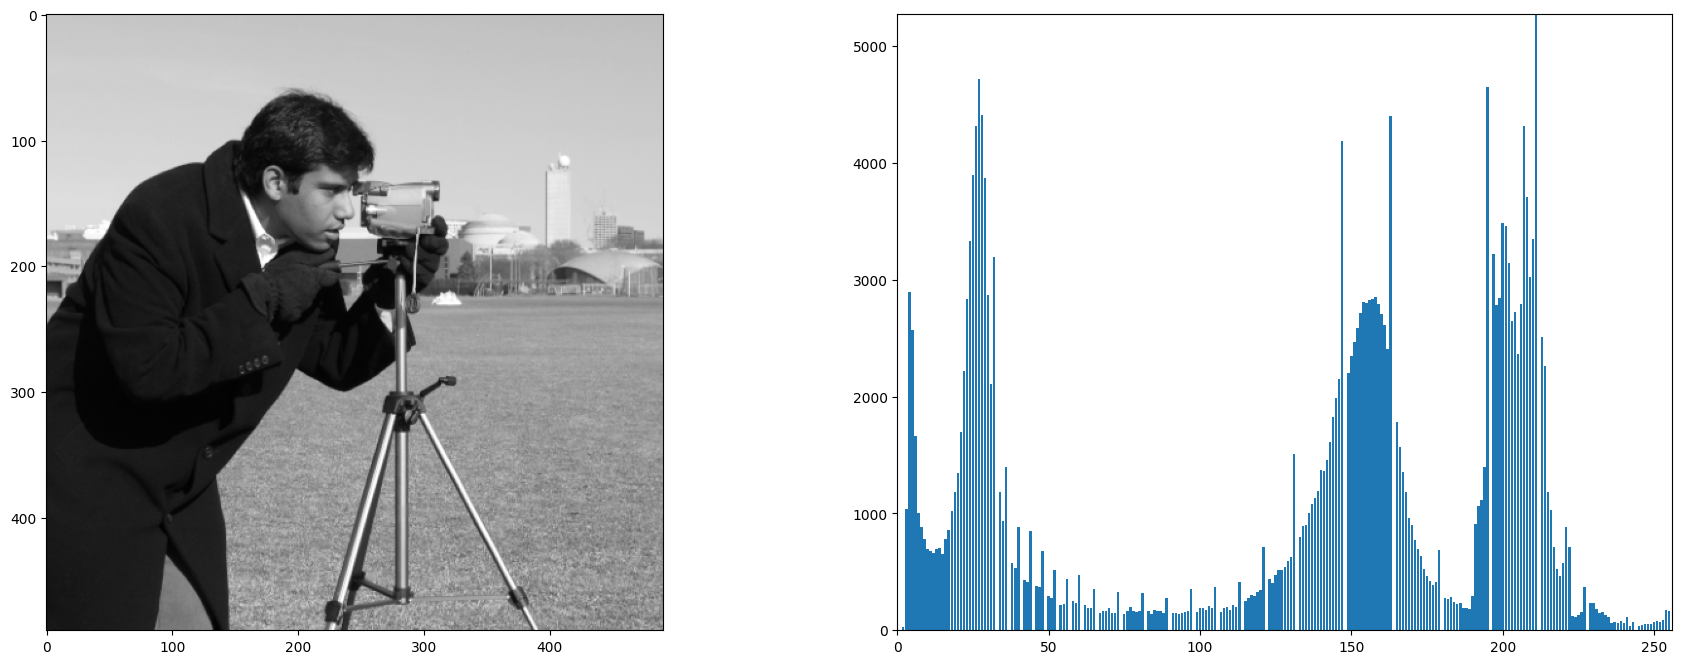

In [ ]:
img = read_file('camera1.tif')[:,:,0]
plot_img_hist(img)

<div dir="rtl">

צעד ראשון: ניצור מטריצה בגדול התמונה ונבדוק לכל פיקסל האם או מעל או מתחת לסף ונקבל מטריצה של True וFalse
<dir>

In [ ]:
img_array = (img > 110)
print(img_array[210:227,:20])

[[ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True]
 [False False False False False False False False False False False False
  False  True  True  True  True  True  True  True]
 [False False False False False False False False False False False False
  False  True  True  True  True  True  True  True]
 [False False False False False False False False False False False False
  False  True  True  True  True  True  True  True]
 [False False False False False False False False False False False False
  False  True  True  True  True  True False False]
 [False False False False False False False False False False False False
  False  True  True  True  True False False False]
 [False False False False False False False False False False False False
  False  True  True  True  True False False False]


<div dir="rtl">

לאחר מכן נמיר כל פיקסל לפי הערך הלוגי שלו - True = 1 (לבן) False = 0 (שחור):
<dir>

In [ ]:
img_1 = (img_array).astype('int16')
print(img_1[210:227,:20])


[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]]


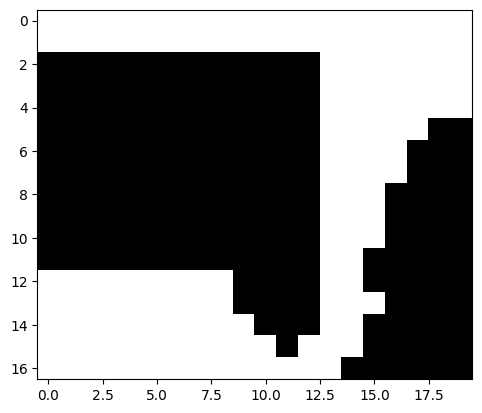

In [ ]:
plt.imshow(img_1[210:227,:20], cmap='gray');

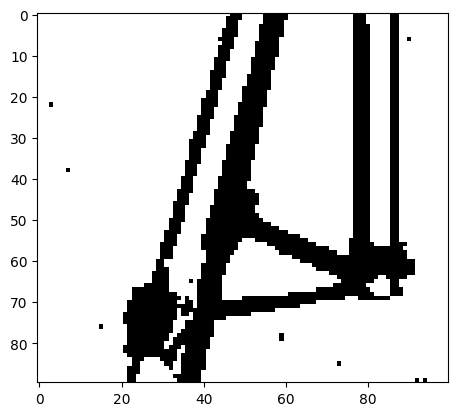

In [ ]:
plt.imshow(img_1[400:,200:300], cmap='gray');

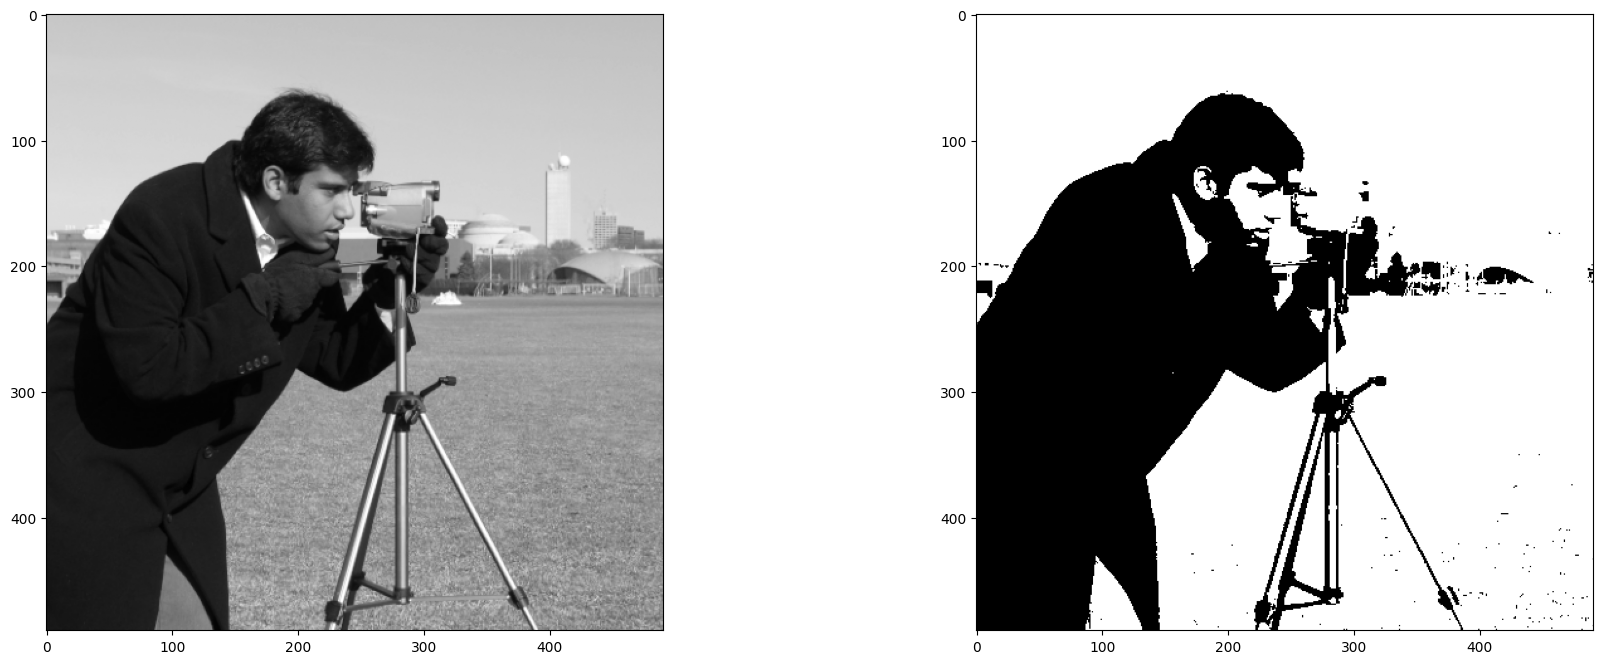

In [ ]:
plot_images(img, img_1)

<div dir="rtl">

מה יקרה אם נבחר סף גבוה מידי?
<dir>

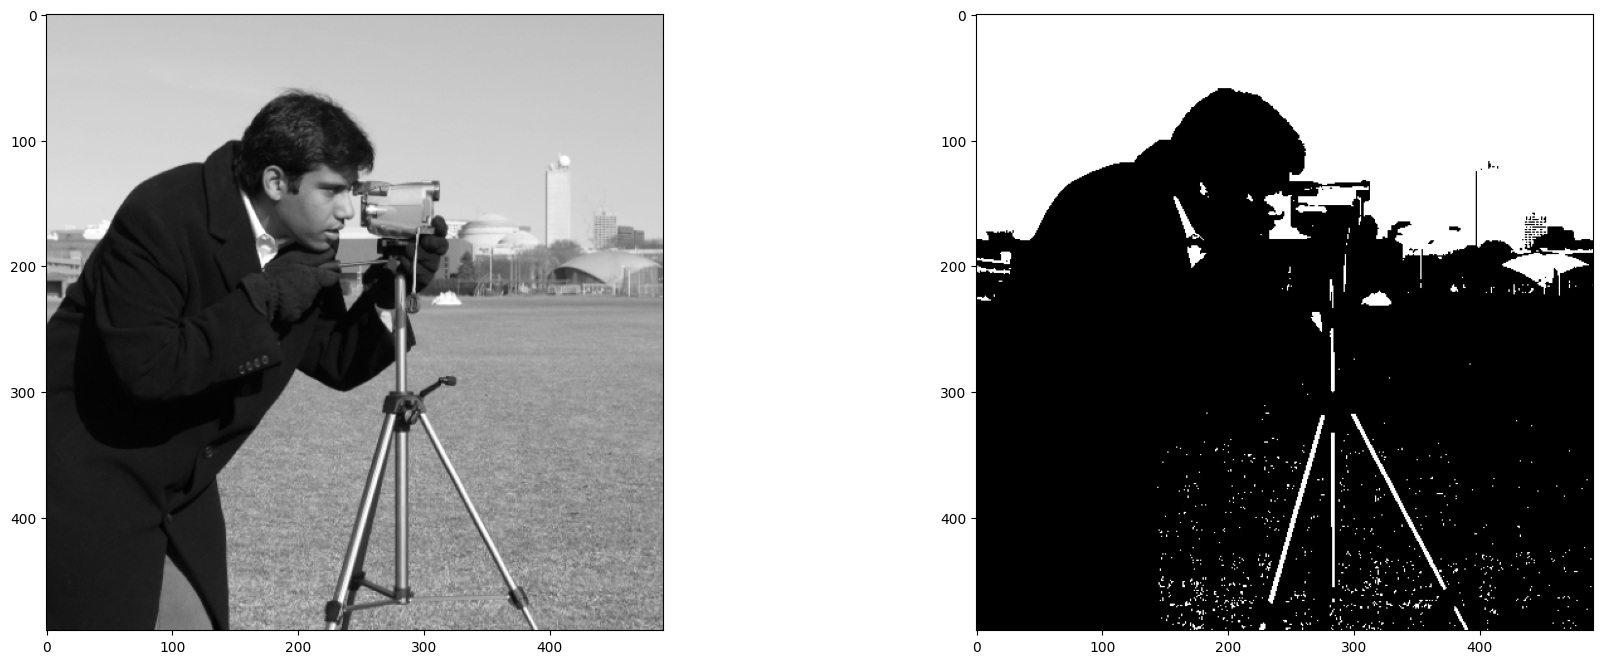

In [ ]:
img_b = (img > 180).astype('int16')
plot_images(img, img_b)

<div dir="rtl">

מה יקרה אם נבחר סף נמוך מידי?
<dir>

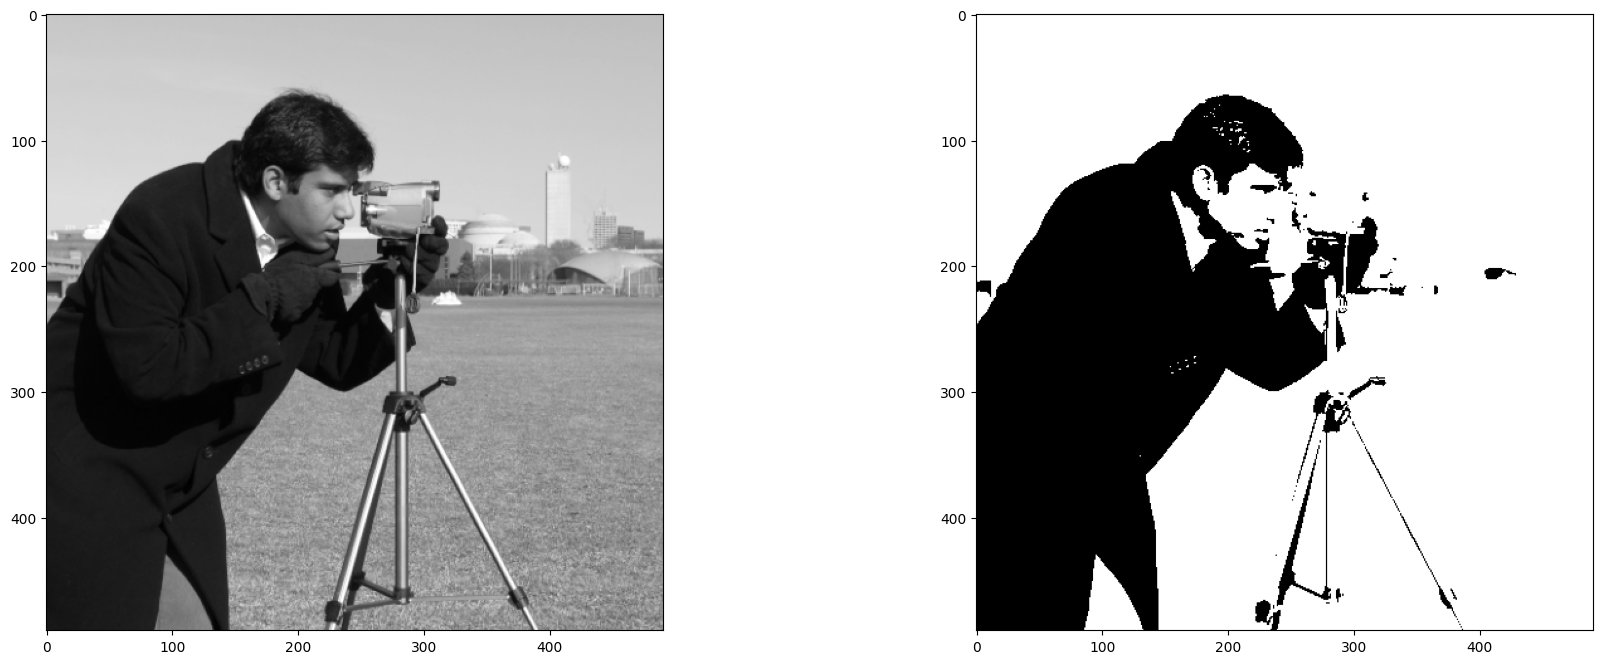

In [ ]:
img_b = (img > 70).astype('int16')
plot_images(img, img_b)

<div dir="rtl">

אם נרצה להכניס גם את הבניינים מאחור בתור אובייקטים, איך אפשר לקבוע את הסף?
<dir>

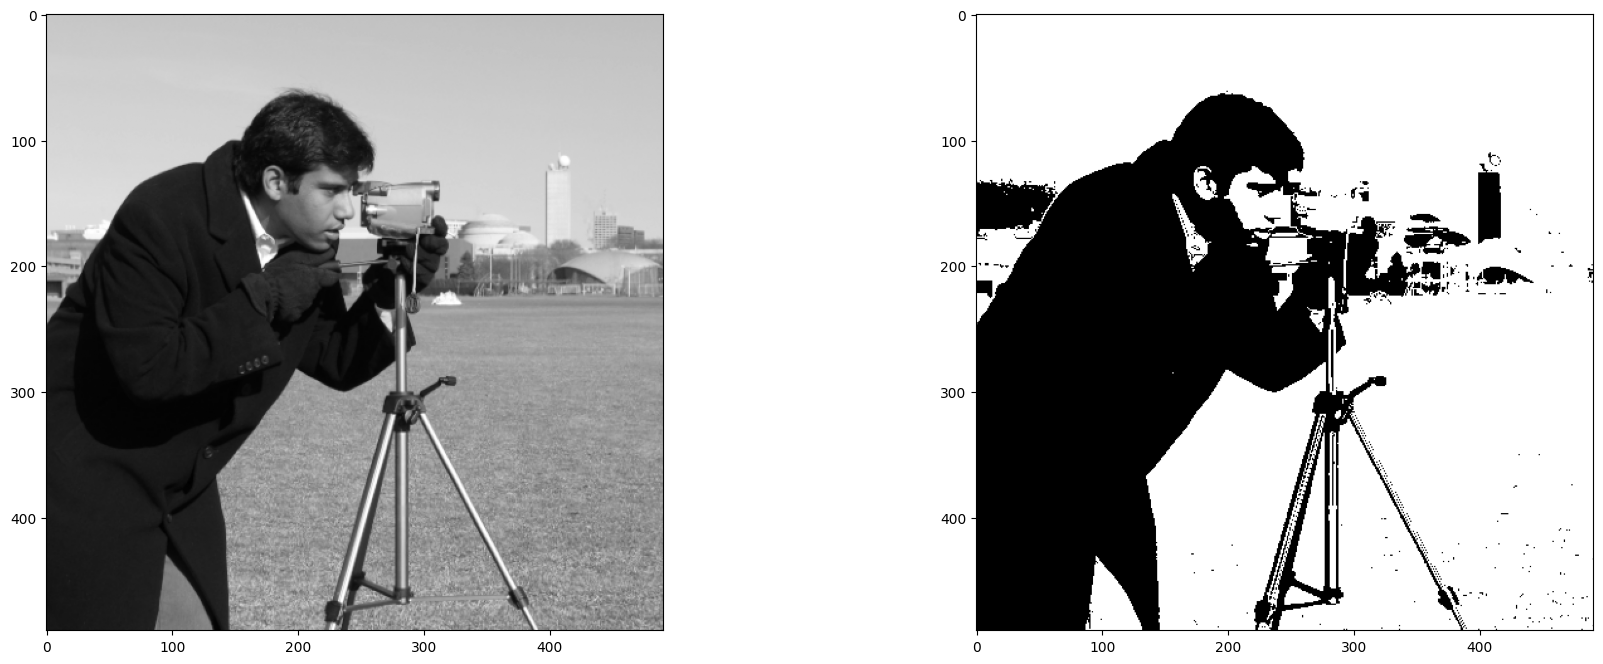

In [ ]:
img_b = (((img > 110) & (img < 220)) | (img > 240)).astype('int16')
plot_images(img, img_b)

<div dir="rtl">

## 7.1 מרכיבים קשירים:

ע"י האלגוריתם הזה אפשר להפריד בין אובייקטים שונים בתמונה ולאחר מכן להפעיל על כל אובייקט אלגוריתמים נוספים שייתנו מידע על שאר המאפיינים שלו (היקף, מרכז מסה ועוד).
<dir>

<div dir="rtl">

### 7.1.1 שכנים:

אפשר לבחור 4 שכנים או 8 שכנים:
<dir>

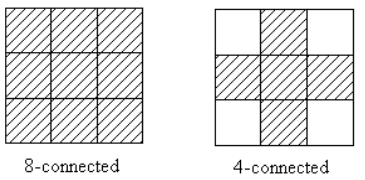

<div dir="rtl">

### 7.1.2 האלגוריתם:

<dir>

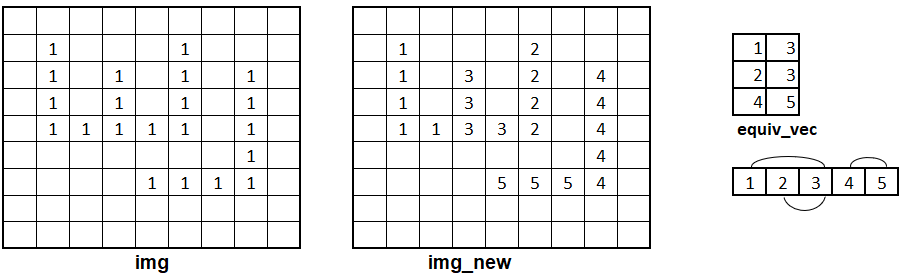

<div dir="rtl">

**שלב 1:**

מעבר על הפיקסלים ותיוג שלהם ויצירת וקטור שקילויות:

* נסרוק את כל הפיקסלים משמאל לימין ומלמעלה למטה
* אם הפיקסל הוא 0 נשים 0 במטריצה החדשה
* אם הפיקסל הוא 1 לוגי אז:
  1. אם גם השכן מלמעלה וגם השכן משמאל הם 0 - נקדם את maxtag + 1 ונוסיף לוקטור השקילויות את הזוג של התג החדש עם עצמו. ונכניס את הערך של התג החדש לפיקסל.
  2. אם רק לאחד השכנים מלמעלה או משמאל יש תגית אז נכניס את הערך שלו לפיקסל
  3. אם לשני השכנים יש תגיות אבל הם שוות - נכניס את הערך של התגית לפיקסל
  4. אם לשני השכנים יש תגיות שונות - נכניס את הערך של התגית העליונה לפיקסל ונוסיף לוקטור השקילויות זוג נוסף של שני התגים של השכנים.

<dir>



```
maxtag = 0
equiv_vec = []
img_new = np.zeros(shape=(img_nrows, img_ncols))    - new matrix, same shape
Scan rows top to bottom and cols left to right. without first and last elements.
1. If img[r,c] == 0
    continue            - (do nothing)
2. if above (img_new[r-1,c]) == 0 and left (img_new[r,c-1]) == 0
     maxtag = maxtag + 1
     equiv_vec.append((maxtag, maxtag))
     img_new[r,c] = maxtag
3. if above > 0 and left == 0 (just above pixel has a tag)
     img_new [r,c] = img_new[r-1,c]
4. if above == 0 and left > 0 (just left pixel has a tag)
     img_new [r,c] = img_new[r,c-1]
5. if above > 0 and left > 0 and above == left (both above and left pixel have tags and tags are the same)
     img_new [r,c] = img_new[r-1,c]
6. if above > 0 and left > 0 and above != left (both above and left pixel have tags and tags are different)
     img_new [r,c] = img_new[r-1,c]
     append (img_newl[r-1,c], img_new[r,c-1]) to equiv_vec
     append (img_new[r,c-1], img_new[r-1,c]) to equiv_vec
```


<div dir="rtl">

**שלב 2:**

יצירת מטריצת קליקות I:

* ניצור מטריצה בגדול (maxtag , maxtag)
* נעבור על כל וקטור השקיליות ולכל זוג קיים נשים במיקום שלו 1

<dir>


    - create cliques matrix (I) size (maxtag, maxtag) of zeros
    - for (tag1, tag2) in equiv_vec: I[tag1-1, tag2-1] = 1

<div dir="rtl">

מה הבעיה שעדיין לא נפתרה?

<dir>


<div dir="rtl">

**שלב 3:**

מציאת קשרים עקיפים:

* ע"י כפל מטריצות של I נמצא גם את הקשרים העקיפים

<dir>



`I2[i, j] == 1 if I[i, k] == 1 and I[j, k] == 1`

In [ ]:
I = np.array([[1,0,1,0,0],
              [0,1,1,0,0],
              [1,1,1,0,0],
              [0,0,0,1,1],
              [0,0,0,1,1]])
I3 = I@I
I3

array([[2, 1, 2, 0, 0],
       [1, 2, 2, 0, 0],
       [2, 2, 3, 0, 0],
       [0, 0, 0, 2, 2],
       [0, 0, 0, 2, 2]])

In [ ]:
I3 = np.minimum(I3, 1)
I3

array([[1, 1, 1, 0, 0],
       [1, 1, 1, 0, 0],
       [1, 1, 1, 0, 0],
       [0, 0, 0, 1, 1],
       [0, 0, 0, 1, 1]])

In [ ]:
I = np.array([[1,0,1,0,0],
              [0,1,0,0,0],
              [1,0,1,0,0],
              [0,0,1,1,1],
              [0,0,0,1,1]])
I2=I.copy()

while True:
    I=I2.copy()
    I2 = I @ I
    print(I2)
    I2 = np.minimum(I2, 1)
    print(I2)
    if (I2 == I).all():
        break

I2


[[2 0 2 0 0]
 [0 1 0 0 0]
 [2 0 2 0 0]
 [1 0 2 2 2]
 [0 0 1 2 2]]
[[1 0 1 0 0]
 [0 1 0 0 0]
 [1 0 1 0 0]
 [1 0 1 1 1]
 [0 0 1 1 1]]
[[2 0 2 0 0]
 [0 1 0 0 0]
 [2 0 2 0 0]
 [3 0 4 2 2]
 [2 0 3 2 2]]
[[1 0 1 0 0]
 [0 1 0 0 0]
 [1 0 1 0 0]
 [1 0 1 1 1]
 [1 0 1 1 1]]
[[2 0 2 0 0]
 [0 1 0 0 0]
 [2 0 2 0 0]
 [4 0 4 2 2]
 [4 0 4 2 2]]
[[1 0 1 0 0]
 [0 1 0 0 0]
 [1 0 1 0 0]
 [1 0 1 1 1]
 [1 0 1 1 1]]


array([[1, 0, 1, 0, 0],
       [0, 1, 0, 0, 0],
       [1, 0, 1, 0, 0],
       [1, 0, 1, 1, 1],
       [1, 0, 1, 1, 1]])

<div dir="rtl">

**שימו לב:**

$I^2_{i,j}=\sum_{{k=1}}^{{n}}{I_{i,k} \times I_{k,j}}$

ולכן אם i קשור לk וk קשור לj אזי i קשור בעקיפין לj.

במילים אחרות יש מסלול בין i לj שעובר דרך k.

ולכן אם נבצע $log(n)$ איטראציות נקבל את כל המסלולים העקיפים האפשריים

<dir>


<div dir="rtl">

**שלב 3:**

ניצור את וקטור ההמרה:

* נסרוק את I2 שורה אחר שורה
* מצא את האינדקס של האפס הראשון.
* הכפל את השורות הבאות בתג הבא ברציפות.

<dir>


```
    cv = I2[0, :]
    tagmin = 1
    cv_len = len(cv)
    for i in range(1, cv_len):
        if cv[i] == 0:
            tagmin = tagmin + 1
            cv = cv + tagmin*I2[i,:]
```


we will get: `cv = [1,1,1,2,2]`

<div dir="rtl">

**שלב 4:**

ניצור את וקטור ההמרה:

נעבור על המטריצה מחדש ונבדוק כל פיקסל של האובייקט מה הערך האמיתי שלו בוקטור ההמרה.

<dir>


```
    for r in range(1, img_nrows):
        for c in range(1, img_ncols):
            if img_new[r, c] > 0:
                    img_new[r,c] = cv[int(img_new[r,c])-1]
```

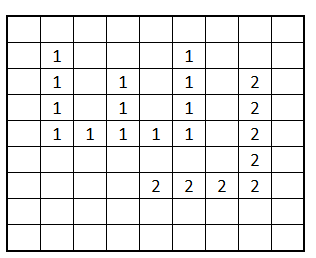